In [1]:
!pip install -q kagglehub

In [6]:
import os
os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/access_token", "w") as f:
    f.write("KGAT_470d97f42d451d908118695b8854b06a")
os.chmod("/root/.kaggle/access_token", 0o600)

In [7]:
!pip install -q kagglehub

In [8]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "jessicali9530/celeba-dataset"
)

print("Dataset path:", dataset_path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
Dataset path: /kaggle/input/celeba-dataset


In [9]:
import os
print(os.listdir(dataset_path))

['list_landmarks_align_celeba.csv', 'img_align_celeba', 'list_eval_partition.csv', 'list_attr_celeba.csv', 'list_bbox_celeba.csv']


In [10]:
import os

for root, dirs, files in os.walk(dataset_path):
    print("Folder:", root)
    print("Number of files:", len(files))

    if len(files) > 0:
        print("Example files:", files[:5])

    print("-" * 50)

Folder: /kaggle/input/celeba-dataset
Number of files: 4
Example files: ['list_landmarks_align_celeba.csv', 'list_eval_partition.csv', 'list_attr_celeba.csv', 'list_bbox_celeba.csv']
--------------------------------------------------
Folder: /kaggle/input/celeba-dataset/img_align_celeba
Number of files: 0
--------------------------------------------------
Folder: /kaggle/input/celeba-dataset/img_align_celeba/img_align_celeba
Number of files: 202599
Example files: ['083648.jpg', '168202.jpg', '125778.jpg', '059339.jpg', '032501.jpg']
--------------------------------------------------


In [11]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow import keras

In [12]:
print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [13]:
image_folder = None
for root, dirs, files in os.walk(dataset_path):
    jpgs = [f for f in files if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    if len(jpgs) > 1000:
        image_folder = root
        break

assert image_folder is not None, "check dataset"
print("Image folder:", image_folder)
print("Example files:", os.listdir(image_folder)[:5])

Image folder: /kaggle/input/celeba-dataset/img_align_celeba/img_align_celeba
Example files: ['083648.jpg', '168202.jpg', '125778.jpg', '059339.jpg', '032501.jpg']


In [14]:
!pip install -q gdown

In [15]:
import gdown

IDENTITY_FILE_ID = "1_ee_0u7vcNLOfNLegJRHmolfH5ICW-XS"
identity_path = "identity_CelebA.txt"

if not os.path.exists(identity_path):
    gdown.download(id=IDENTITY_FILE_ID, output=identity_path, quiet=False)

identity_df = pd.read_csv(
    identity_path,
    sep=r"\s+",
    header=None,
    names=["file", "identity"],
)
print(identity_df.shape)
identity_df.head()

Downloading...
From: https://drive.google.com/uc?id=1_ee_0u7vcNLOfNLegJRHmolfH5ICW-XS
To: /content/identity_CelebA.txt
100%|██████████| 3.42M/3.42M [00:00<00:00, 26.5MB/s]


(202599, 2)


,file,identity
0,000001.jpg,2880
1,000002.jpg,2937
2,000003.jpg,8692
3,000004.jpg,5805
4,000005.jpg,9295


In [18]:
available_files = set(os.listdir(image_folder))

person_to_images = {}
for fname, pid in zip(identity_df["file"], identity_df["identity"]):
    if fname in available_files:
        person_to_images.setdefault(int(pid), []).append(fname)

print("People total:", len(person_to_images))

person_to_images = {p: imgs for p, imgs in person_to_images.items() if len(imgs) >= 2}
print("People with >=2 images:", len(person_to_images))
print("Total images used:", sum(len(v) for v in person_to_images.values()))

People total: 10177
People with >=2 images: 10133
Total images used: 202555


In [19]:
people = list(person_to_images.keys())
random.shuffle(people)

split = int(len(people) * 0.8)
train_people = people[:split]
test_people = people[split:]

train_dict = {p: person_to_images[p] for p in train_people}
test_dict = {p: person_to_images[p] for p in test_people}

print("Train people:", len(train_dict), "| Test people:", len(test_dict))

Train people: 8106 | Test people: 2027


In [20]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

def load_image(image_name):
    path = os.path.join(image_folder, image_name)
    img = Image.open(path).convert("RGB")
    img = img.resize(IMG_SIZE)
    img = np.array(img, dtype=np.float32) / 255.0
    return img

def positive_pair(data):
    persons = [p for p in data if len(data[p]) >= 2]
    person = random.choice(persons)
    img1, img2 = random.sample(data[person], 2)
    return img1, img2, 1

def negative_pair(data):
    p1, p2 = random.sample(list(data.keys()), 2)
    img1 = random.choice(data[p1])
    img2 = random.choice(data[p2])
    return img1, img2, 0

def pair_generator(data, batch_size):
    while True:
        img1_batch, img2_batch, label_batch = [], [], []
        for _ in range(batch_size):
            if random.random() < 0.5:
                n1, n2, label = positive_pair(data)
            else:
                n1, n2, label = negative_pair(data)
            img1_batch.append(load_image(n1))
            img2_batch.append(load_image(n2))
            label_batch.append(label)
        yield (
            (np.array(img1_batch, dtype=np.float32), np.array(img2_batch, dtype=np.float32)),
            np.array(label_batch, dtype=np.float32),
        )

In [21]:
output_signature = (
    (
        tf.TensorSpec(shape=(None, *IMG_SIZE, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, *IMG_SIZE, 3), dtype=tf.float32),
    ),
    tf.TensorSpec(shape=(None,), dtype=tf.float32),
)

train_ds = tf.data.Dataset.from_generator(
    lambda: pair_generator(train_dict, BATCH_SIZE),
    output_signature=output_signature,
).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_generator(
    lambda: pair_generator(test_dict, BATCH_SIZE),
    output_signature=output_signature,
).prefetch(tf.data.AUTOTUNE)

In [22]:
class L2Normalize(keras.layers.Layer):
    def call(self, x):
        return tf.math.l2_normalize(x, axis=1)

    def compute_output_shape(self, input_shape):
        return input_shape


def create_encoder(input_shape):
    inputs = keras.Input(shape=input_shape)

    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(256, 3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    embedding = layers.Dense(128, activation=None, name="embedding")(x)
    embedding = L2Normalize()(embedding)

    return keras.Model(inputs, embedding, name="encoder")


input_shape = (*IMG_SIZE, 3)
encoder = create_encoder(input_shape)
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2_normalize (L2Normalize)      │ (None, 128)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 489,024 (1.87 MB)

 Trainable params: 488,064 (1.86 MB)

 Non-trainable params: 960 (3.75 KB)

In [23]:
class L1Distance(keras.layers.Layer):
    def call(self, inputs):
        a, b = inputs
        return tf.abs(a - b)

    def compute_output_shape(self, input_shape):
        return input_shape[0]


input1 = keras.Input(shape=input_shape, name="image1")
input2 = keras.Input(shape=input_shape, name="image2")

feature1 = encoder(input1)
feature2 = encoder(input2)

l1_distance = L1Distance()([feature1, feature2])
output = layers.Dense(1, activation="sigmoid")(l1_distance)

model = keras.Model([input1, input2], output, name="siamese_face_verification")
model.summary()

Model: "siamese_face_verification"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image1 (InputLayer) │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image2 (InputLayer) │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder             │ (None, 128)       │    489,024 │ image1[0][0],     │
│ (Functional)        │                   │            │ image2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ l1_distance         │ (None, 128)       │          0 │ encoder[0][0],    │
│ (L1Distance)        │                   │            │ encoder[1][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        129 │ l1_distance[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 489,153 (1.87 MB)

 Trainable params: 488,193 (1.86 MB)

 Non-trainable params: 960 (3.75 KB)

In [24]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

In [25]:
EPOCHS = 20
STEPS_PER_EPOCH = 200
VALIDATION_STEPS = 50

history = model.fit(
    train_ds,
    steps_per_epoch=STEPS_PER_EPOCH,
    epochs=EPOCHS,
    validation_data=test_ds,
    validation_steps=VALIDATION_STEPS,
)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 113s 505ms/step - accuracy: 0.5055 - loss: 0.6939 - val_accuracy: 0.5269 - val_loss: 0.6920
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 100s 504ms/step - accuracy: 0.5295 - loss: 0.6885 - val_accuracy: 0.5356 - val_loss: 0.6856
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 93s 467ms/step - accuracy: 0.5295 - loss: 0.6889 - val_accuracy: 0.5494 - val_loss: 0.6825
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 88s 443ms/step - accuracy: 0.5478 - loss: 0.6862 - val_accuracy: 0.5369 - val_loss: 0.6895
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 77s 385ms/step - accuracy: 0.5559 - loss: 0.6850 - val_accuracy: 0.5350 - val_loss: 0.6875
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 69s 347ms/step - accuracy: 0.5611 - loss: 0.6823 - val_accuracy: 0.5600 - val_loss: 0.6811
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 63s 316ms/step - accuracy: 0.5658 - loss: 0.6810 - val_accuracy: 0.5512 - val_loss: 0.6801
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 58s 294ms/step - accuracy: 0.5644 - loss:

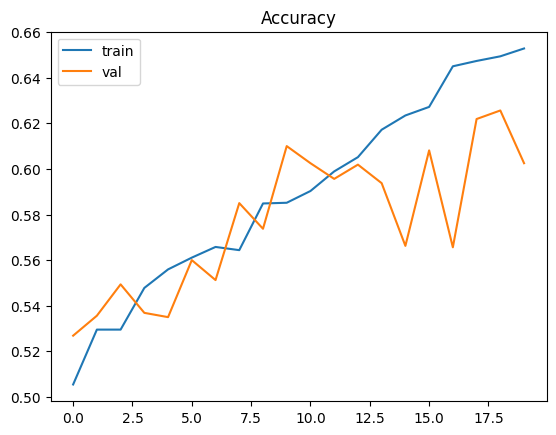

In [26]:
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.legend()
plt.title("Accuracy")
plt.show()

In [27]:
model.save("celeba_siamese_face_verification.keras")
encoder.save("face_encoder.keras")
print("Saved.")

Saved.
